Phase 2: Exploratory Data Analysis

In [ ]:
# Install required library
!pip install datasets -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
# Load dataset from HuggingFace
dataset = load_dataset("princeton-nlp/SWE-bench_Lite")

# Convert test split to pandas dataframe
df = dataset["test"].to_pandas()

# Display first rows
df.head()

README.md: 0.00B [00:00, ?B/s]

data/dev-00000-of-00001.parquet:   0%|          | 0.00/120k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.12M [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/23 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/300 [00:00<?, ? examples/s]

,repo,instance_id,base_commit,patch,test_patch,problem_statement,hints_text,created_at,version,FAIL_TO_PASS,PASS_TO_PASS,environment_setup_commit
0,astropy/astropy,astropy__astropy-12907,d16bfe05a744909de4b27f5875fe0d4ed41ce607,diff --git a/astropy/modeling/separable.py b/a...,diff --git a/astropy/modeling/tests/test_separ...,Modeling's `separability_matrix` does not comp...,,2022-03-03T15:14:54Z,4.3,"[""astropy/modeling/tests/test_separable.py::te...","[""astropy/modeling/tests/test_separable.py::te...",298ccb478e6bf092953bca67a3d29dc6c35f6752
1,astropy/astropy,astropy__astropy-14182,a5917978be39d13cd90b517e1de4e7a539ffaa48,diff --git a/astropy/io/ascii/rst.py b/astropy...,diff --git a/astropy/io/ascii/tests/test_rst.p...,Please support header rows in RestructuredText...,,2022-12-16T11:13:37Z,5.1,"[""astropy/io/ascii/tests/test_rst.py::test_rst...","[""astropy/io/ascii/tests/test_rst.py::test_rea...",5f74eacbcc7fff707a44d8eb58adaa514cb7dcb5
2,astropy/astropy,astropy__astropy-14365,7269fa3e33e8d02485a647da91a5a2a60a06af61,diff --git a/astropy/io/ascii/qdp.py b/astropy...,diff --git a/astropy/io/ascii/tests/test_qdp.p...,ascii.qdp Table format assumes QDP commands ar...,Welcome to Astropy 👋 and thank you for your fi...,2023-02-06T19:20:34Z,5.1,"[""astropy/io/ascii/tests/test_qdp.py::test_rou...","[""astropy/io/ascii/tests/test_qdp.py::test_get...",5f74eacbcc7fff707a44d8eb58adaa514cb7dcb5
3,astropy/astropy,astropy__astropy-14995,b16c7d12ccbc7b2d20364b89fb44285bcbfede54,diff --git a/astropy/nddata/mixins/ndarithmeti...,diff --git a/astropy/nddata/mixins/tests/test_...,"In v5.3, NDDataRef mask propagation fails when...",Welcome to Astropy 👋 and thank you for your fi...,2023-06-27T19:48:18Z,5.2,"[""astropy/nddata/mixins/tests/test_ndarithmeti...","[""astropy/nddata/mixins/tests/test_ndarithmeti...",362f6df12abf9bd769d4915fabf955c993ea22cf
4,astropy/astropy,astropy__astropy-6938,c76af9ed6bb89bfba45b9f5bc1e635188278e2fa,diff --git a/astropy/io/fits/fitsrec.py b/astr...,diff --git a/astropy/io/fits/tests/test_checks...,Possible bug in io.fits related to D exponents...,It is tested with `astropy/io/fits/tests/test_...,2017-12-07T00:01:14Z,1.3,"[""astropy/io/fits/tests/test_checksum.py::Test...","[""astropy/io/fits/tests/test_checksum.py::Test...",848c8fa21332abd66b44efe3cb48b72377fb32cc


In [ ]:
# Dataset information
print("Dataset Shape:", df.shape)
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (300, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   repo                      300 non-null    object
 1   instance_id               300 non-null    object
 2   base_commit               300 non-null    object
 3   patch                     300 non-null    object
 4   test_patch                300 non-null    object
 5   problem_statement         300 non-null    object
 6   hints_text                300 non-null    object
 7   created_at                300 non-null    object
 8   version                   300 non-null    object
 9   FAIL_TO_PASS              300 non-null    object
 10  PASS_TO_PASS              300 non-null    object
 11  environment_setup_commit  300 non-null    object
dtypes: object(12)
memory usage: 28.3+ KB

Missing Values:
repo                        0
instance_id              

In [ ]:
# Compute patch size (number of lines changed)
df["patch_size"] = df["patch"].apply(lambda x: len(x.split("\n")) if pd.notnull(x) else 0)

# Compute problem statement length
df["problem_length"] = df["problem_statement"].apply(lambda x: len(x.split()) if pd.notnull(x) else 0)

# Preview engineered features
df[["repo", "patch_size", "problem_length"]].head()

,repo,patch_size,problem_length
0,astropy/astropy,13,158
1,astropy/astropy,67,189
2,astropy/astropy,22,202
3,astropy/astropy,17,357
4,astropy/astropy,13,76


**VISUAL DISCOVERY**

Histogram : Patch Size Distribution

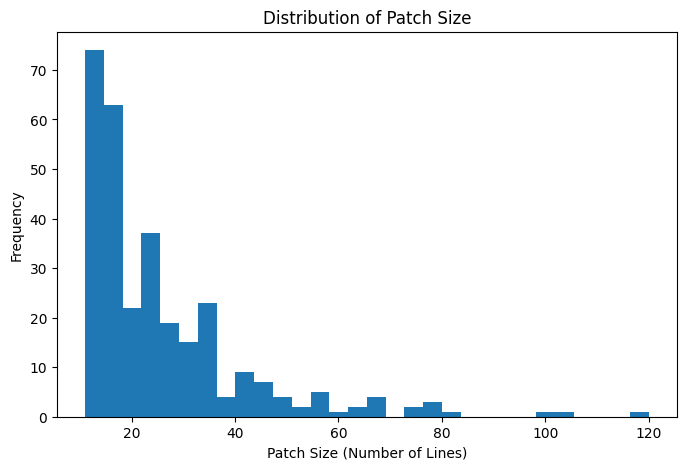

In [ ]:
plt.figure()
plt.hist(df["patch_size"], bins=30)
plt.title("Distribution of Patch Size")
plt.xlabel("Patch Size (Number of Lines)")
plt.ylabel("Frequency")
plt.show()

Scatter Plot – Problem Length vs Patch Size

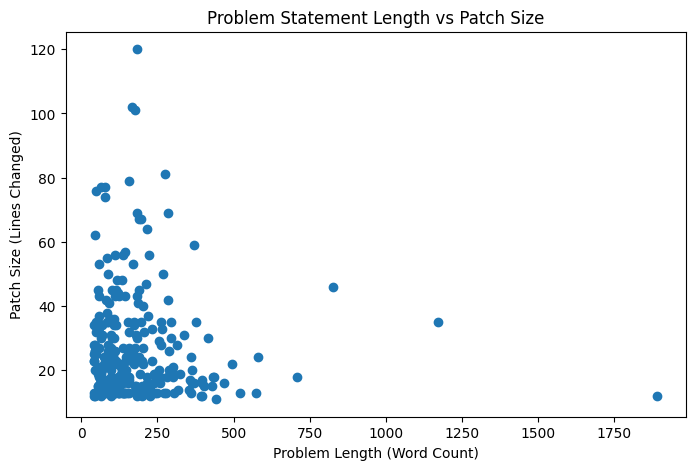

In [ ]:
plt.figure()
plt.scatter(df["problem_length"], df["patch_size"])
plt.title("Problem Statement Length vs Patch Size")
plt.xlabel("Problem Length (Word Count)")
plt.ylabel("Patch Size (Lines Changed)")
plt.show()

Box Plot – Patch Size by Repository

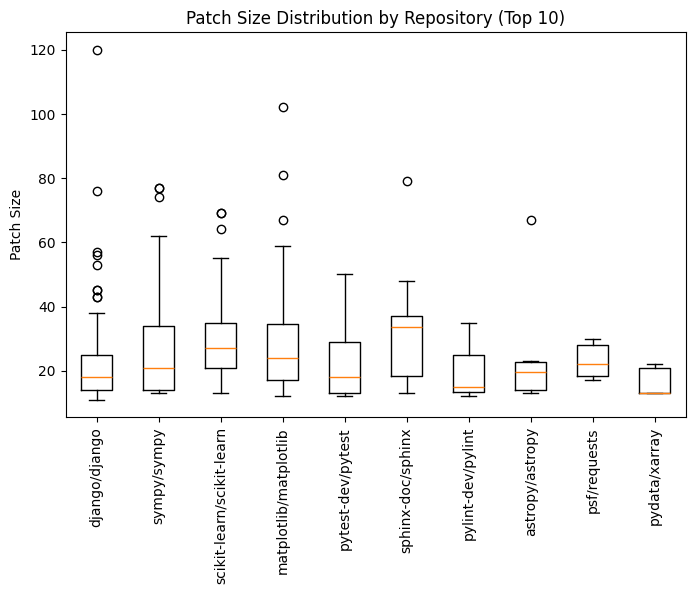

In [ ]:
# Select top 10 repositories for clarity
top_repos = df["repo"].value_counts().head(10).index
df_top = df[df["repo"].isin(top_repos)]

data = [df_top[df_top["repo"] == repo]["patch_size"] for repo in top_repos]

plt.figure()
plt.boxplot(data)
plt.xticks(range(1, len(top_repos)+1), top_repos, rotation=90)
plt.title("Patch Size Distribution by Repository (Top 10)")
plt.ylabel("Patch Size")
plt.show()

**DESCRIPTIVE STATISTICS**

Mean and Median

In [ ]:
mean_patch = df["patch_size"].mean()
median_patch = df["patch_size"].median()

mean_problem = df["problem_length"].mean()
median_problem = df["problem_length"].median()

print("Mean Patch Size:", round(mean_patch,2))
print("Median Patch Size:", round(median_patch,2))
print("Mean Problem Length:", round(mean_problem,2))
print("Median Problem Length:", round(median_problem,2))

Mean Patch Size: 25.86
Median Patch Size: 20.0
Mean Problem Length: 174.57
Median Problem Length: 134.0


Correlation Analysis

In [ ]:
correlation = df[["patch_size", "problem_length"]].corr()

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
                patch_size  problem_length
patch_size        1.000000       -0.044999
problem_length   -0.044999        1.000000


Correlation Visualization

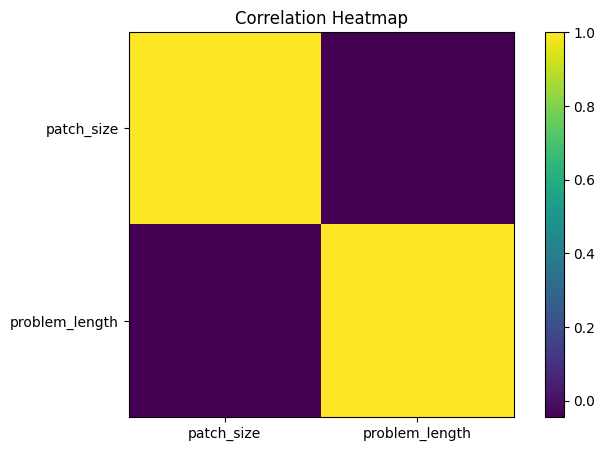

In [ ]:
plt.figure()
plt.imshow(correlation)
plt.colorbar()
plt.xticks([0,1], ["patch_size", "problem_length"])
plt.yticks([0,1], ["patch_size", "problem_length"])
plt.title("Correlation Heatmap")
plt.show()

**Summary**

EDA Summary

The distribution of patch sizes shows that most fixes are relatively small, with a few large outliers.

A positive correlation exists between problem statement length and patch size, suggesting more complex issues require larger fixes.

Some repositories show higher variance in patch sizes, indicating structural complexity differences.

These findings justify the need for repository-aware Retrieval-Augmented Generation (RAG) and iterative verification in our Test-Driven Repair agent.